In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

sns.set()

In [2]:
breast_cancer_data = load_breast_cancer()

x_df = pd.DataFrame(breast_cancer_data.data, columns=breast_cancer_data.feature_names)

print(x_df.head())
print(x_df.info())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [3]:
x_df = x_df[["mean area", "mean compactness"]]
print(x_df.head())

   mean area  mean compactness
0     1001.0           0.27760
1     1326.0           0.07864
2     1203.0           0.15990
3      386.1           0.28390
4     1297.0           0.13280


In [4]:
y_df = pd.Categorical.from_codes(
    breast_cancer_data.target,
    breast_cancer_data.target_names
)

print(y_df)

['malignant', 'malignant', 'malignant', 'malignant', 'malignant', ..., 'malignant', 'malignant', 'malignant', 'malignant', 'benign']
Length: 569
Categories (2, object): ['malignant', 'benign']


In [5]:
y_df = pd.get_dummies(y_df, drop_first=True)
print(y_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   benign  569 non-null    bool 
dtypes: bool(1)
memory usage: 701.0 bytes
None


In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    x_df,
    y_df,
    random_state=1,
    test_size=0.25,
    shuffle=True
)

print(x_test.info())

<class 'pandas.core.frame.DataFrame'>
Index: 143 entries, 421 to 415
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   mean area         143 non-null    float64
 1   mean compactness  143 non-null    float64
dtypes: float64(2)
memory usage: 3.4 KB
None


In [7]:
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(metric='euclidean')

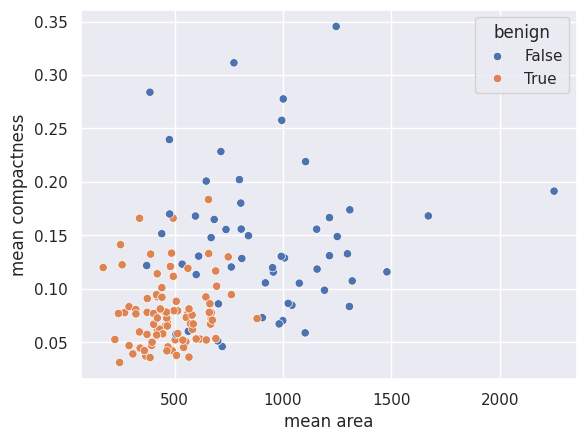

In [8]:
combined_df = pd.concat([x_test, y_test], axis=1)

sns.scatterplot(
    x="mean area",
    y="mean compactness",
    hue="benign",
    data=combined_df
)

plt.show()

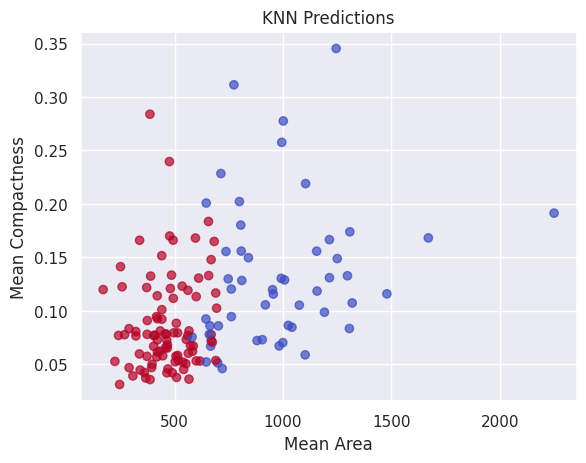

In [9]:
y_pred = knn.predict(x_test)

plt.scatter(
    x_test["mean area"],
    x_test["mean compactness"],
    c=y_pred,
    cmap="coolwarm",
    alpha=0.7
)

plt.xlabel("Mean Area")
plt.ylabel("Mean Compactness")
plt.title("KNN Predictions")

plt.show()

In [10]:
cf = confusion_matrix(y_test, y_pred)
print(cf)

[[42 13]
 [ 9 79]]


In [11]:
tp, fn, fp, tn = confusion_matrix(y_test, y_pred, labels=[1, 0]).reshape(-1)
print(tp, fn, fp, tn)

79 9 13 42


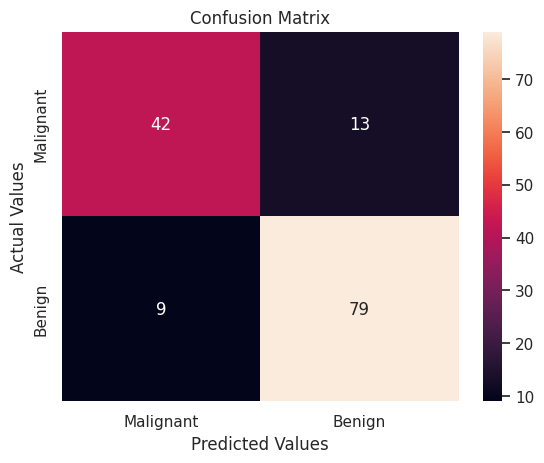

In [12]:
labels = ["True Negatives", "False Positive", "False Negative", "True Positive"]
labels = np.asarray(labels).reshape(2, 2)

ax = plt.subplot()
sns.heatmap(cf, annot=True, fmt="d", ax=ax)

ax.set_xlabel("Predicted Values")
ax.set_ylabel("Actual Values")
ax.set_title("Confusion Matrix")

ax.xaxis.set_ticklabels(["Malignant", "Benign"])
ax.yaxis.set_ticklabels(["Malignant", "Benign"])

plt.show()

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")

Accuracy: 0.85
Precision: 0.86
Recall: 0.90
F1 Score: 0.88


In [14]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


Detailed Classification Report:
              precision    recall  f1-score   support

   Malignant       0.82      0.76      0.79        55
      Benign       0.86      0.90      0.88        88

    accuracy                           0.85       143
   macro avg       0.84      0.83      0.84       143
weighted avg       0.85      0.85      0.84       143

